# 🤖 مشروع Multi-Agent Research System (Supervisor Architecture)

نظام بحث متعدد الإيجنتس مبني بـ **LangGraph** + **Ollama** (نموذج محلي) +
**MCP** (Model Context Protocol) للأدوات الخارجية.

## المعمارية
```
START → Supervisor ⇄ (Research | Extraction | Analysis | Reviewer | Summary) → END
```

- **Supervisor Agent**: بيقرر مين الإيجنت اللي يشتغل بعد كل خطوة، بناءً على حالة
  المشروع الحالية، وبيحاول يوصل لأفضل نتيجة ممكنة.
- **حدود صارمة (Hard Limits) لكل إيجنت**: كل إيجنت له حد أقصى لعدد مرات
  التنفيذ. لو السوبرفايزر (أو الموديل الصغير) حاول يخالف الحد أو يخالف
  الترتيب المنطقي للمشروع، في **شبكة أمان بالكود العادي (deterministic)**
  بترفض القرار وتصحّحه تلقائيًا — عشان نموذج صغير زي `qwen2.5:3b` ميقدرش
  "يكسر" تدفق العمل حتى لو اتلخبط.
- **MCP Server حقيقي**: سيرفر منفصل شغال على `localhost:8000/mcp` فيه أداة
  `search_web` بتدور فعليًا على الإنترنت (بدون أي API key).

## قبل ما تشغل النوتبوك
1. **شغّل Ollama** وحمّل الموديل:
   ```bash
   ollama pull qwen2.5:3b
   ```
2. **ثبّت المكتبات**:
   ```bash
   pip install langgraph langchain-ollama langchain-mcp-adapters langchain-core \
               fastmcp ddgs pydantic python-dotenv
   ```
3. **شغّل سيرفر الـ MCP** (في terminal منفصل، وسيبه شغال):
   ```bash
   python mcp_server/search_server.py
   ```
   لازم تشوف رسالة إنه شغال على `http://0.0.0.0:8000/mcp` قبل ما تكمل.


## 1) الاستيرادات (Imports)

In [1]:
from typing import TypedDict, Literal, Optional

from pydantic import BaseModel, Field

from langchain_ollama import ChatOllama
from langchain_mcp_adapters.client import MultiServerMCPClient

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver


## 2) الإعدادات والحدود (Config & Limits)

هنا بنحدد **أقصى عدد مرات** ممكن كل إيجنت يشتغل فيها. ده اللي بيمنع أي
loop لا نهائي، وبيجبر السوبرفايزر إنه لما إيجنت يخلص حده، يعدي بأفضل
نتيجة متاحة للمرحلة اللي بعدها.

In [39]:
# أقصى عدد مرات تنفيذ لكل إيجنت
AGENT_LIMITS = {
    "research": 5,
    "extraction": 1,
    "analysis": 3,
    "reviewer": 2,
    "summary": 1,
}

MAX_TOTAL_STEPS = 20   # حماية إضافية من أي infinite loop عام
MAX_SEARCH_RESULTS = 8
MAX_DOCUMENTS = 5


## 3) حالة المشروع (State)

In [55]:
class ResearchState(TypedDict):
    query: str

    research_results: list
    documents: list
    analysis: str
    review: dict
    summary: str

    # أفضل نسخة متاحة من كل مرحلة (بتتحدث أول ما الإيجنت يشتغل)
    best_analysis: str
    best_review: dict

    step_count: int
    agent_calls: dict          # {"research": 2, "analysis": 1, ...}
    execution_history: list

    next_agent: str
    supervisor_reason: str


def make_initial_state(query: str) -> ResearchState:
    return {
        "query": query,
        "research_results": [],
        "documents": [],
        "analysis": "",
        "review": {},
        "summary": "",
        "best_analysis": "",
        "best_review": {},
        "step_count": 0,
        "agent_calls": {k: 0 for k in AGENT_LIMITS},
        "execution_history": [],
        "next_agent": "",
        "supervisor_reason": "",
    }


initial_state = make_initial_state("What is liberalism?")


## 4) الموديلات (LLMs)

بنستخدم نفس الموديل المحلي (`qwen2.5:3b` عبر Ollama) في 3 أشكال:
- `llm`: للاستخدام العام (analysis, summary).
- `supervisor_llm`: مربوط بـ `SupervisorDecision` (structured output) عشان
  السوبرفايزر يرجع قرار منظم دايمًا.
- `review_llm`: مربوط بـ `ReviewResult` عشان المراجع يرجع تقييم منظم.


In [56]:
llm = ChatOllama(
    model="qwen2.5:3b",
    temperature=0,
)


In [57]:
# اختبار سريع للتأكد إن Ollama شغال ومتجاوب
response = llm.invoke("Explain MCP in one sentence.")
print(response.content)


MCP (Managed Compute Resources) is a service in Alibaba Cloud that allows users to easily manage and scale compute resources for their applications.


## 5) الاتصال بسيرفر MCP

لازم يكون `mcp_server/search_server.py` شغال قبل الخطوة دي (شوف التعليمات
فوق). هنتصل بيه ونجيب الأدوات المتاحة، وناخد أداة `search_web`.

In [58]:
mcp_client = MultiServerMCPClient(
    {
        "research_tools": {
            "transport": "streamable_http",
            "url": "http://localhost:8000/mcp",
        }
    }
)

tools = await mcp_client.get_tools()

for tool in tools:
    print(f"Tool: {tool.name}")
    print(f"Description: {tool.description}")
    print("-" * 50)


Tool: search_web
Description: يدور على الإنترنت عن استعلام معين ويرجع أهم النتائج.
--------------------------------------------------


In [59]:
search_tool = next(
    tool for tool in tools if tool.name == "search_web"
)
search_tool


StructuredTool(name='search_web', description='يدور على الإنترنت عن استعلام معين ويرجع أهم النتائج.', args_schema={'additionalProperties': False, 'properties': {'query': {'type': 'string', 'description': 'نص البحث.'}, 'max_results': {'default': 5, 'type': 'integer', 'description': 'أقصى عدد نتائج (افتراضي 5).'}}, 'required': ['query'], 'type': 'object'}, metadata={'_meta': {'fastmcp': {'tags': []}}}, handle_tool_error=<function _handle_mcp_tool_error at 0x00000210A0748720>, response_format='content_and_artifact', coroutine=<function convert_mcp_tool_to_langchain_tool.<locals>.call_tool at 0x00000210A4AE1760>)

## 6) الإيجنتس (Agent Nodes)

كل إيجنت بيرجع تحديث لل-state فيه:
- الناتج الخاص بيه (نتائج بحث / مستندات / تحليل / مراجعة / ملخص)
- `step_count` و `agent_calls` و `execution_history` محدّثين

ملحوظة مهمة: إيجنت الـ `research` بيجمّع (`+=`) النتائج بدل ما يستبدلها،
عشان لو السوبرفايزر قرر يبحث تاني، النتائج الجديدة تتضاف مش تمسح القديمة.

In [60]:
def _bump(state: ResearchState, agent_name: str) -> dict:
    """تحديثات مشتركة كل إيجنت لازم يرجعها."""
    calls = dict(state["agent_calls"])
    calls[agent_name] = calls.get(agent_name, 0) + 1
    return {
        "step_count": state["step_count"] + 1,
        "agent_calls": calls,
        "execution_history": state["execution_history"] + [agent_name],
    }


async def research_agent(state: ResearchState):
    attempt = state["agent_calls"].get("research", 0) + 1
    print(f"\n🔎 RESEARCH AGENT (محاولة رقم {attempt}/{AGENT_LIMITS['research']})")

    results = await search_tool.ainvoke(
        {"query": state["query"], "max_results": MAX_SEARCH_RESULTS}
    )

    combined = state["research_results"] + (
        results if isinstance(results, list) else [results]
    )

    return {
        "research_results": combined,
        **_bump(state, "research"),
    }


async def extraction_agent(state: ResearchState):
    print("\n📄 EXTRACTION AGENT")

    documents = [
        {"title": f"Research Result {i+1}", "content": r}
        for i, r in enumerate(state["research_results"])
    ]

    return {
        "documents": documents,
        **_bump(state, "extraction"),
    }


async def analysis_agent(state: ResearchState):
    attempt = state["agent_calls"].get("analysis", 0) + 1
    print(f"\n🧠 ANALYSIS AGENT (محاولة رقم {attempt}/{AGENT_LIMITS['analysis']})")

    context = "\n\n".join(str(doc) for doc in state["documents"][:MAX_DOCUMENTS])

    feedback_block = ""
    if state["review"].get("decision") == "NEEDS_MORE":
        feedback_block = f"""
ملاحظات المراجع على المحاولة السابقة (لازم تعالجها):
- سبب: {state['review'].get('reason', '')}
- نواقص محددة: {state['review'].get('missing_information', [])}

Improve the analysis to cover these gaps.
"""

    prompt = f"""أنت Analysis Agent.

سؤال المستخدم:
{state['query']}

بيانات البحث:
{context}
{feedback_block}

Analyze the data and identify:
1. Key findings
2. Important facts
3. Trends
4. Limitations of the available data

Do not discuss the project itself; provide only the analysis."""

    response = await llm.ainvoke(prompt)
    analysis_text = response.content

    return {
        "analysis": analysis_text,
        "best_analysis": analysis_text,
        **_bump(state, "analysis"),
    }


class ReviewResult(BaseModel):
    decision: Literal["APPROVED", "NEEDS_MORE"]
    reason: str
    missing_information: list[str]


review_llm = llm.with_structured_output(ReviewResult)


async def reviewer_agent(state: ResearchState):
    attempt = state["agent_calls"].get("reviewer", 0) + 1
    print(f"\n🔍 REVIEWER AGENT (محاولة رقم {attempt}/{AGENT_LIMITS['reviewer']})")

    prompt = f"""You are a rigorous research reviewer.

السؤال: {state['query']}
التحليل: {state['analysis']}

Evaluate whether the analysis is sufficient to answer the question usefully.
Do not conduct any additional research. If anything is missing, clearly identify it."""

    try:
        result = await review_llm.ainvoke(prompt)
        review_dict = result.model_dump()
    except Exception as e:
        # لو الموديل الصغير رجّع output مش متوافق مع الـ schema،
        # منمنعش المشروع من الاستمرار
        review_dict = {
            "decision": "APPROVED",
            "reason": f"تعذر تقييم دقيق ({e}), تم القبول احتياطيًا.",
            "missing_information": [],
        }

    return {
        "review": review_dict,
        "best_review": review_dict,
        **_bump(state, "reviewer"),
    }


async def summary_agent(state: ResearchState):
    print("\n📝 SUMMARY AGENT")

    analysis_used = state["best_analysis"] or state["analysis"]

    prompt = f"""أنت Summary Agent.

السؤال: {state['query']}
التحليل النهائي المتاح: {analysis_used}
نتيجة المراجعة: {state['best_review'] or state['review']}

Provide a clear and concise final answer.
Transparently indicate any missing information.
Do not invent information that is not present in the analysis."""

    response = await llm.ainvoke(prompt)

    return {
        "summary": response.content,
        **_bump(state, "summary"),
    }


In [61]:
def _bump(state: ResearchState, agent_name: str) -> dict:
    """تحديثات مشتركة كل إيجنت لازم يرجعها."""
    calls = dict(state["agent_calls"])
    calls[agent_name] = calls.get(agent_name, 0) + 1
    return {
        "step_count": state["step_count"] + 1,
        "agent_calls": calls,
        "execution_history": state["execution_history"] + [agent_name],
    }


async def research_agent(state: ResearchState):
    attempt = state["agent_calls"].get("research", 0) + 1
    print(f"\n🔎 RESEARCH AGENT (محاولة رقم {attempt}/{AGENT_LIMITS['research']})")

    results = await search_tool.ainvoke(
        {"query": state["query"], "max_results": MAX_SEARCH_RESULTS}
    )

    combined = state["research_results"] + (
        results if isinstance(results, list) else [results]
    )

    return {
        "research_results": combined,
        **_bump(state, "research"),
    }


async def extraction_agent(state: ResearchState):
    print("\n📄 EXTRACTION AGENT")

    documents = [
        {"title": f"Research Result {i+1}", "content": r}
        for i, r in enumerate(state["research_results"])
    ]

    return {
        "documents": documents,
        **_bump(state, "extraction"),
    }


async def analysis_agent(state: ResearchState):
    attempt = state["agent_calls"].get("analysis", 0) + 1
    print(f"\n🧠 ANALYSIS AGENT (محاولة رقم {attempt}/{AGENT_LIMITS['analysis']})")

    context = "\n\n".join(str(doc) for doc in state["documents"][:MAX_DOCUMENTS])

    feedback_block = ""
    if state["review"].get("decision") == "NEEDS_MORE":
        feedback_block = f"""
ملاحظات المراجع على المحاولة السابقة (لازم تعالجها):
- سبب: {state['review'].get('reason', '')}
- نواقص محددة: {state['review'].get('missing_information', [])}

Improve the analysis to cover these gaps.
"""

    prompt = f"""you are Analysis Agent.

سؤال المستخدم:
{state['query']}

بيانات البحث:
{context}
{feedback_block}

Analyze the data and identify:
1. Key findings
2. Important facts
3. Trends
4. Limitations of the available data

Do not discuss the project itself; provide only the analysis."""

    response = await llm.ainvoke(prompt)
    analysis_text = response.content

    return {
        "analysis": analysis_text,
        "best_analysis": analysis_text,
        **_bump(state, "analysis"),
    }


class ReviewResult(BaseModel):
    decision: Literal["APPROVED", "NEEDS_MORE"]
    reason: str
    missing_information: list[str]


review_llm = llm.with_structured_output(ReviewResult)


async def reviewer_agent(state: ResearchState):
    attempt = state["agent_calls"].get("reviewer", 0) + 1
    print(f"\n🔍 REVIEWER AGENT (محاولة رقم {attempt}/{AGENT_LIMITS['reviewer']})")

    prompt = f"""You are a rigorous research reviewer.

السؤال: {state['query']}
التحليل: {state['analysis']}

Evaluate whether the analysis is sufficient to answer the question usefully.
Do not conduct any additional research. If anything is missing, clearly identify it."""

    try:
        result = await review_llm.ainvoke(prompt)
        review_dict = result.model_dump()
    except Exception as e:
        # لو الموديل الصغير رجّع output مش متوافق مع الـ schema،
        # منمنعش المشروع من الاستمرار
        review_dict = {
            "decision": "APPROVED",
            "reason": f"تعذر تقييم دقيق ({e}), تم القبول احتياطيًا.",
            "missing_information": [],
        }

    return {
        "review": review_dict,
        "best_review": review_dict,
        **_bump(state, "reviewer"),
    }


async def summary_agent(state: ResearchState):
    print("\n📝 SUMMARY AGENT")

    analysis_used = state["best_analysis"] or state["analysis"]

    prompt = f"""أنت Summary Agent.

السؤال: {state['query']}
التحليل النهائي المتاح: {analysis_used}
نتيجة المراجعة: {state['best_review'] or state['review']}

Provide a clear and concise final answer.
Transparently indicate any missing information.
Do not invent information that is not present in the analysis."""

    response = await llm.ainvoke(prompt)

    return {
        "summary": response.content,
        **_bump(state, "summary"),
    }


## 7) السوبرفايزر (Supervisor)

السوبرفايزر بيسأل الموديل "مين الإيجنت الجاي؟" (بـ structured output)،
بس أي قرار بيتفحص أولاً بدالة `is_eligible` قبل ما ينفّذ. لو القرار مش
منطقي (يخالف حد، أو يقفز مرحلة)، بيتصحح تلقائيًا بمنطق حتمي
(`compute_fallback_agent`) — ده بالظبط اللي بيضمن المشروع يخلص لآخره
حتى لو الموديل الصغير اتلخبط.

In [62]:
class SupervisorDecision(BaseModel):
    next_agent: Literal[
        "research", "extraction", "analysis", "reviewer", "summary", "finish"
    ]
    reason: str = Field(description="سبب قصير للقرار")


supervisor_llm = llm.with_structured_output(SupervisorDecision)


def _remaining(state: ResearchState) -> dict:
    return {
        agent: AGENT_LIMITS[agent] - state["agent_calls"].get(agent, 0)
        for agent in AGENT_LIMITS
    }


def is_eligible(agent: str, state: ResearchState) -> bool:
    """هل القرار ده منطقي ومسموح دلوقتي؟"""
    calls = state["agent_calls"]

    def has_budget(a: str) -> bool:
        return calls.get(a, 0) < AGENT_LIMITS[a]

    # لو already عملنا summary، الحاجة الوحيدة المسموحة هي finish
    if calls.get("summary", 0) >= 1:
        return agent == "finish"

    if agent == "finish":
        return bool(state["summary"]) or all(not has_budget(a) for a in AGENT_LIMITS)

    if agent == "research":
        return has_budget("research") and calls.get("extraction", 0) == 0

    if agent == "extraction":
        return (
            has_budget("extraction")
            and calls.get("research", 0) >= 1
            and calls.get("analysis", 0) == 0
        )

    if agent == "analysis":
        return has_budget("analysis") and calls.get("extraction", 0) >= 1

    if agent == "reviewer":
        return has_budget("reviewer") and calls.get("analysis", 0) >= 1

    if agent == "summary":
        review_decision = state["review"].get("decision")
        loop_still_open = has_budget("analysis") and has_budget("reviewer")
        return (
            has_budget("summary")
            and calls.get("analysis", 0) >= 1
            and calls.get("reviewer", 0) >= 1
            and (review_decision == "APPROVED" or not loop_still_open)
        )

    return False


def compute_fallback_agent(state: ResearchState) -> tuple[str, str]:
    """قرار حتمي 100% مضمون إنه eligible دايمًا."""
    calls = state["agent_calls"]

    if calls.get("research", 0) == 0:
        return "research", "لازم بيانات بحث قبل أي حاجة تانية."
    if calls.get("extraction", 0) == 0:
        return "extraction", "عندنا نتائج بحث؛ وقت الاستخراج."
    if calls.get("analysis", 0) == 0:
        return "analysis", "عندنا مستندات؛ وقت التحليل الأول."
    if calls.get("summary", 0) >= 1:
        return "finish", "تم إصدار الملخص النهائي بالفعل."

    if calls.get("reviewer", 0) < calls.get("analysis", 0) and is_eligible("reviewer", state):
        return "reviewer", "فيه تحليل جديد محتاج مراجعة."

    review_decision = state["review"].get("decision")
    if (
        review_decision == "NEEDS_MORE"
        and is_eligible("analysis", state)
        and AGENT_LIMITS["reviewer"] - calls.get("reviewer", 0) > 0
    ):
        return "analysis", "المراجع طلب تحسين التحليل وفيه محاولات متبقية."

    if is_eligible("summary", state):
        return "summary", "التحليل والمراجعة جاهزين؛ وقت التلخيص النهائي."

    return "finish", "كل الحدود المتاحة اتستنفذت أو خلصنا كل المراحل."


def build_supervisor_prompt(state: ResearchState) -> str:
    remaining = _remaining(state)
    eligible_now = [a for a in list(AGENT_LIMITS) + ["finish"] if is_eligible(a, state)]

    return f"""أنت Supervisor Agent بيدير فريق إيجنتس عشان يجاوب على سؤال بحثي بأفضل نتيجة ممكنة.

السؤال: {state['query']}

تم تنفيذ حتى الآن: {state['execution_history'] or 'لسه معملش حاجة'}
عدد نتائج البحث: {len(state['research_results'])}
عدد المستندات: {len(state['documents'])}
يوجد تحليل حالي: {'نعم' if state['analysis'] else 'لا'}
نتيجة آخر مراجعة: {state['review'] or 'لا يوجد بعد'}
يوجد ملخص نهائي: {'نعم' if state['summary'] else 'لا'}

الحد الأقصى المتبقي لكل إيجنت: {remaining}
الخيارات المسموحة فعليًا دلوقتي فقط: {eligible_now}

Select only one of the "allowed options" and briefly explain your reasoning.
If the reviewer requests "NEEDS_MORE" and there are remaining analysis/reviewer attempts, it is usually best to revert to the analysis stage.
If no further improvement is required, proceed normally to the next stage.
"""


def enforce_limits(raw_agent: str, state: ResearchState) -> tuple[str, Optional[str]]:
    """شبكة الأمان: بترجع القرار كما هو لو eligible، وإلا تستبدله بقرار حتمي صحيح."""
    if is_eligible(raw_agent, state):
        return raw_agent, None

    fallback_agent, fallback_reason = compute_fallback_agent(state)
    override_reason = (
        f"تم تجاوز قرار السوبرفايزر ('{raw_agent}' غير مسموح به الآن) "
        f"والانتقال لـ '{fallback_agent}': {fallback_reason}"
    )
    return fallback_agent, override_reason


In [63]:
async def supervisor_node(state: ResearchState):
    # حماية قصوى من أي loop لا نهائي
    if state["step_count"] >= MAX_TOTAL_STEPS:
        return {
            "next_agent": "finish",
            "supervisor_reason": "تم الوصول للحد الأقصى الكلي للخطوات.",
            "execution_history": state["execution_history"] + ["supervisor"],
        }

    prompt = build_supervisor_prompt(state)

    try:
        decision: SupervisorDecision = await supervisor_llm.ainvoke(prompt)
        raw_agent, raw_reason = decision.next_agent, decision.reason
    except Exception as e:
        raw_agent, raw_reason = compute_fallback_agent(state)
        raw_reason = f"{raw_reason} (فشل الـ LLM: {e})"

    final_agent, override_reason = enforce_limits(raw_agent, state)
    reason = override_reason or raw_reason

    print(f"\n🧭 SUPERVISOR -> {final_agent} | {reason}")

    return {
        "next_agent": final_agent,
        "supervisor_reason": reason,
        "execution_history": state["execution_history"] + ["supervisor"],
    }


def supervisor_router(state: ResearchState):
    return state["next_agent"]


## 8) بناء الـ Graph

**تصحيح مهم عن النسخة الأولى:** كل إيجنت دلوقتي بيرجع للسوبرفايزر
(`add_edge(agent, "supervisor")`) بعد ما يخلص، بدل ما يقف من غير أي
edge (وده كان بيمنع أي تكرار أو تحكم حقيقي من السوبرفايزر).

In [64]:
builder = StateGraph(ResearchState)

builder.add_node("supervisor", supervisor_node)
builder.add_node("research", research_agent)
builder.add_node("extraction", extraction_agent)
builder.add_node("analysis", analysis_agent)
builder.add_node("reviewer", reviewer_agent)
builder.add_node("summary", summary_agent)

builder.add_edge(START, "supervisor")

builder.add_conditional_edges(
    "supervisor",
    supervisor_router,
    {
        "research": "research",
        "extraction": "extraction",
        "analysis": "analysis",
        "reviewer": "reviewer",
        "summary": "summary",
        "finish": END,
    },
)

# كل إيجنت يرجع للسوبرفايزر بعد ما يخلص عشان يقرر الخطوة الجاية
for agent_name in ["research", "extraction", "analysis", "reviewer", "summary"]:
    builder.add_edge(agent_name, "supervisor")

checkpointer = MemorySaver()
research_graph = builder.compile(checkpointer=checkpointer)


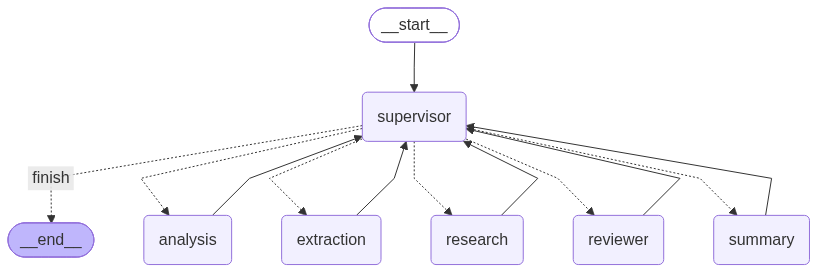

In [65]:
from IPython.display import Image, display

display(Image(research_graph.get_graph().draw_mermaid_png()))


## 9) LangSmith 

لو عندك `.env` فيه `LANGSMITH_API_KEY` و `LANGSMITH_PROJECT`، الخلية دي
هتفعّل التتبع تلقائيًا. لو مش موجود، هتكمل عادي من غير tracing.

In [66]:
import os
from dotenv import load_dotenv

load_dotenv()

langsmith_project = os.getenv("LANGSMITH_PROJECT")
if langsmith_project:
    print(f"LangSmith tracing enabled for project: {langsmith_project}")
else:
    print("LangSmith مش متفعّل (اختياري) - هنكمل عادي من غيره.")


LangSmith tracing enabled for project: AI-Research-MCP


In [67]:
config = {
    "configurable": {"thread_id": "research-001"},
    "recursion_limit": 30,
    "run_name": "AI Research Multi-Agent",
    "tags": ["multi-agent", "mcp", "langgraph", "qwen"],
    "metadata": {
        "model": "qwen2.5:3b",
        "architecture": "supervisor-with-hard-limits",
        "agent_limits": AGENT_LIMITS,
    },
}


## 10) تشغيل المشروع كامل

In [68]:
async for update in research_graph.astream(
    initial_state,
    config=config,
    stream_mode="updates",
):
    print("\n" + "=" * 60)
    for node, output in update.items():
        print(f"NODE: {node}")



🧭 SUPERVISOR -> research | تم تجاوز قرار السوبرفايزر ('extraction' غير مسموح به الآن) والانتقال لـ 'research': لازم بيانات بحث قبل أي حاجة تانية.

NODE: supervisor

🔎 RESEARCH AGENT (محاولة رقم 1/5)

NODE: research

🧭 SUPERVISOR -> research | البحث عن المصادر والمراجعات لفهم مفهوم الليبرالية بشكل أفضل هو الخطوة الأكثر فعالية في هذه المرحلة.

NODE: supervisor

🔎 RESEARCH AGENT (محاولة رقم 2/5)

NODE: research

🧭 SUPERVISOR -> research | البحث عن المصادر والمراجعات الأولية للحصول على معلومات أكثر حول liberalism هو خطوة أولية مهمة قبل الانتقال إلى التحليل وال.extraction.

NODE: supervisor

🔎 RESEARCH AGENT (محاولة رقم 3/5)

NODE: research

🧭 SUPERVISOR -> research | البحث عن المصادر والمراجعات الأولية للحصول على معلومات أكثر حول liberalism هو خطوة أولية مهمة قبل الانتقال إلى التحليل وال.extraction.

NODE: supervisor

🔎 RESEARCH AGENT (محاولة رقم 4/5)

NODE: research

🧭 SUPERVISOR -> research | البحث عن مصادر إضافية لمعرفة المزيد عن liberalism يمكن أن يوفر معلومات أكثر دقة وعمقاً حول هذا 

In [69]:
final_state = research_graph.get_state(config).values

print("=" * 60)
print("📊 ملخص التنفيذ")
print("=" * 60)
print("عدد مرات كل إيجنت:", final_state["agent_calls"])
print("الترتيب الكامل:", final_state["execution_history"])
print("\n" + "=" * 60)
print("📝 الإجابة النهائية")
print("=" * 60)
print(final_state["summary"])


📊 ملخص التنفيذ
عدد مرات كل إيجنت: {'research': 5, 'extraction': 1, 'analysis': 3, 'reviewer': 2, 'summary': 1}
الترتيب الكامل: ['supervisor', 'research', 'supervisor', 'research', 'supervisor', 'research', 'supervisor', 'research', 'supervisor', 'research', 'supervisor', 'extraction', 'supervisor', 'analysis', 'supervisor', 'analysis', 'supervisor', 'analysis', 'supervisor', 'reviewer', 'supervisor', 'reviewer', 'supervisor', 'summary', 'supervisor']

📝 الإجابة النهائية
Liberalism is a philosophy that emphasizes the importance of human individuality and the liberation of the individual from complete subservience to the group. It advocates for a relaxation of the tight hold of custom, law, and authority, and seeks to replace existing institutions with representative democracy, rule of law, and equality under the law. Liberalism is characterized by a focus on protecting and enhancing the freedom of the individual. It is often associated with classical liberalism, which is described as "a